<a href="https://colab.research.google.com/github/ourharlequin/ai_workbooks/blob/main/Workshop_5_AI_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Workshop: AI Agents

**Lecture 5 — AI Agents + Gradio**

In this workshop, you will:
1. Build an AI agent from scratch in plain Python (~20 lines)
2. Rebuild it with LangGraph nodes for structure and control
3. Add a quality-grading node (Agentic RAG exercise)
4. Use the pre-built `create_agent()` for quick prototyping
5. Wrap your agent in a Gradio chat UI

> We'll be building a **customer support agent** for Acme Inc. — continuing from the lecture.

⏱️ **Time:** ~45 minutes

---
## Section 0 — Setup & Configuration

In [1]:
# 0.1  Install dependencies
# fmt: off
!uv pip install -q \
    langchain==1.2.14 \
    langchain-core \
    langchain-litellm \
    langchain-community \
    langgraph==1.1.5 \
    gradio
# fmt: on

In [5]:
# 0.2  Choose your LLM provider
#
# LiteLLM lets you use the same interface for any provider.
# Uncomment ONE block below and paste your API key.

import os
from google.colab import userdata

#os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
#LLM_MODEL = "openai/gpt-5-nano"

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
LLM_MODEL = "gemini/gemini-2.5-flash"

# os.environ["MISTRAL_API_KEY"] = userdata.get("MISTRAL_API_KEY")
# LLM_MODEL = "mistral/mistral-small-latest"

# os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
# LLM_MODEL = "openrouter/openai/gpt-5.4-nano"

In [3]:
# 0.3  Imports

from IPython.display import Image, display

from langchain_litellm import ChatLiteLLM
from langchain_core.messages import (
    AIMessage, HumanMessage, SystemMessage, ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

In [6]:
# 0.4  Initialize the LLM
#
# ChatLiteLLM supports tool calling across all providers above.
# LiteLLM translates tool schemas to each provider's native format.

llm = ChatLiteLLM(model=LLM_MODEL)

# Quick test
response = llm.invoke("Say hello in 3 languages.")
print(response.content)

Hello! Hola! Bonjour!


### 0.5 — Customer Support Tools

These are the same tools from the lecture (slides 26–28).
In production, they'd call real APIs. Here we use mock data.

In [7]:
# 0.5  Customer support tools (mock implementations)

ORDERS = {
    "1234": {"status": "shipped", "shipped_days_ago": 3, "eta": "tomorrow",
             "item": "laptop", "amount": 999.99, "tracking_number": "EE12345555RR"},
    "5678": {"status": "processing", "shipped_days_ago": 0, "eta": "3-5 days",
             "item": "headphones", "amount": 149.99, "tracking_number": "-"},
    "9999": {"status": "delivered", "shipped_days_ago": 7, "eta": "delivered",
             "item": "keyboard", "amount": 79.99, "tracking_number": "LL12349999QQ"},
}

FAQ = {
    "return policy": "Items can be returned within 30 days of delivery with a receipt.",
    "shipping time": "Standard shipping takes 3-5 business days.",
    "warranty": "All electronics come with a 1-year manufacturer warranty.",
    "address change": "Address changes are not possible after an order has shipped. Contact the carrier directly.",
    "payment methods": "We accept Visa, Mastercard, PayPal, and Apple Pay.",
}


# 'tool' decorator inspects the function and create a schema with its name, description and signature.
# This schema will then be sent to the LLM.
@tool
def check_order_status(order_id: str) -> str:
    """Check the current status of a customer order by order ID."""
    order = ORDERS.get(order_id)
    if not order:
        return f"Order {order_id} not found."
    return (
        f"Order #{order_id}: {order['item']} (${order['amount']:.2f}) — "
        f"Status: {order['status']}. "
        f"Shipped {order['shipped_days_ago']} days ago. "
        f"ETA: {order['eta']}. "
        f"Tracking number: {order['tracking_number']}."
    )


@tool
def search_faq(query: str) -> str:
    """Search the FAQ knowledge base for an answer to a customer question."""
    query_lower = query.lower()
    for topic, answer in FAQ.items():
        if any(word in query_lower for word in topic.split()):
            return f"FAQ ({topic}): {answer}"
    return "No matching FAQ found. Consider escalating to a human agent."


@tool
def calculate_refund(amount: float, reason: str) -> str:
    """Calculate refund amount based on the original price and return reason."""
    if reason.lower() in ("defective", "damaged", "wrong item"):
        refund = amount  # full refund
    else:
        refund = amount * 0.85  # 15% restocking fee
    return f"Refund for ${amount:.2f} ({reason}): ${refund:.2f}"


tools = [check_order_status, search_faq, calculate_refund]
print(f"Defined {len(tools)} tools: {[t.name for t in tools]}")

Defined 3 tools: ['check_order_status', 'search_faq', 'calculate_refund']


---
## Section 1 — Agent in Plain Python

No frameworks. No graphs. Just a `while` loop that:
1. Calls the LLM with the conversation history
2. Checks if the LLM wants to call tools
3. Executes the tools and appends results
4. Repeats until the LLM gives a final answer

This is the core of every agent — the **ReAct loop** from the lecture.

In [ ]:
# 1.1  The agent loop — plain Python

SYSTEM_PROMPT = (
    "You are a customer support agent for Acme Inc. "
    "Help customers with order status, returns, refunds, and general questions. "
    "Use the provided tools when needed. Be concise and helpful."
)

# Map tool names to functions for execution
tool_map = {t.name: t for t in tools}

# Bind tools to the LLM so it knows what's available and their schemas.
# Then the LLM can return either a reply or a tool call (as text).
llm_with_tools = llm.bind_tools(tools)

def run_agent(user_message: str) -> str:
    """Run the customer support agent on a single query."""
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=user_message),
    ]

    print(f"User: {user_message}")
    print("-" * 50)

    while True:
        # Call the LLM
        response = llm_with_tools.invoke(messages)
        messages.append(response)

        # If no tool calls, we have the final answer
        # Consider: is it always the best stragegy? Are there alternatives?
        if not response.tool_calls:
            print(f"Agent: {response.content}")
            return response.content

        # Execute each tool call
        for tc in response.tool_calls:
            print(f"  Tool: {tc['name']}({tc['args']})")
            result = tool_map[tc["name"]].invoke(tc["args"])
            print(f"  Result: {result}")
            messages.append(
                ToolMessage(content=str(result), tool_call_id=tc["id"])
            )

        print()

In [ ]:
# 1.2  Test the agent

result = run_agent("Where is my order #1234?")

User: Where is my order #1234?
--------------------------------------------------
  Tool: check_order_status({'order_id': '1234'})
  Result: Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.

Agent: Your order #1234 is shipped.

- Status: Shipped (3 days ago)
- ETA: tomorrow
- Tracking number: EE12345555RR

You can track it on the carrier’s website using the tracking number. Want me to send you a tracking link or set up alerts (email/SMS) for updates? I can also check again after the ETA passes.


In [ ]:
# 1.3  Multi-step query

result = run_agent(
    "I want to return a laptop I bought last week. Order #1234."
  )

User: I want to return a laptop I bought last week. Order #1234.
--------------------------------------------------
  Tool: check_order_status({'order_id': '1234'})
  Result: Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  Tool: search_faq({'query': 'return policy electronics laptop return window restocking fee label'})
  Result: FAQ (return policy): Items can be returned within 30 days of delivery with a receipt.

Agent: Here's what I found for Order #1234:
- Status: shipped 3 days ago
- ETA: tomorrow
- Item: laptop

Return policy note:
- You can return items within 30 days of delivery with a receipt.
- Since delivery hasn’t happened yet, the 30-day return window starts on the delivery date.

What would you like to do?
- I can help you start the return as soon as the package is delivered.
- If you’re hoping to intercept delivery, I can check with the carrier for options (availability varies).

Tell me which option yo

In [ ]:
# 1.4  Query that requires multiple tools

result = run_agent(
    "How long do I have to return items? "
    "And what's my refund on a $149.99 order if I just changed my mind?"
)

User: How long do I have to return items? And what's my refund on a $149.99 order if I just changed my mind?
--------------------------------------------------
  Tool: search_faq({'query': 'return window policy'})
  Result: FAQ (return policy): Items can be returned within 30 days of delivery with a receipt.
  Tool: calculate_refund({'amount': 149.99, 'reason': 'change of mind'})
  Result: Refund for $149.99 (change of mind): $127.49

Agent: - Return window: 30 days from delivery, with a receipt.
- Refund for a $149.99 order (change of mind): $127.49 (includes a 15% restocking fee).

If you’d like, I can start the return process for you. Please share your order number and whether you want me to generate a prepaid shipping label.


### **You don't always need a framework**

- The plain Python loop above is a real agent. For many use cases, this is all you need.
- So why would you add a framework? As agents grow more complex, a flat while loop gets harder to read and maintain.
- LangGraph lets you express the same logic as a graph: each step is a node, each decision is an edge. You can visualize the flow, persist state across restarts, and test nodes in isolation.

| Approach | Lines | Strength | Limitation |
|----------|-------|----------|------------|
| Plain Python loop | ~20 | Simple, transparent | Hard to add branching, retries, visualization |
| LangGraph nodes | ~40–60 | Structure, visualization, conditional routing | More setup |
| `create_agent()` | ~5 | Fastest to start | Limited customization |

---
## Section 2 — Agent with LangGraph

Same customer support agent, now as a LangGraph `StateGraph`.

The graph has two nodes:
- **`call_model`** — calls the LLM
- **`call_tools`** — executes tool calls

And conditional routing: if the LLM returns tool calls → go to `call_tools` → loop back. If not → end.

In [ ]:
# 2.1  Build the LangGraph agent

def call_model(state: MessagesState) -> dict:
    """Call the LLM with the current messages."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


def should_continue(state: MessagesState) -> str:
    """Route: if the last message has tool calls, continue. Otherwise, end."""
    last = state["messages"][-1]
    if last.tool_calls:
        return "call_tools"
    return END


# Build the graph
graph = StateGraph(MessagesState)
graph.add_node("call_model", call_model)  # invoke LLM
graph.add_node("call_tools", ToolNode(tools))  # invoke tools

graph.add_edge(START, "call_model")
graph.add_conditional_edges("call_model", should_continue, ["call_tools", END])
graph.add_edge("call_tools", "call_model")

agent = graph.compile()
print("Graph compiled successfully!")

Graph compiled successfully!


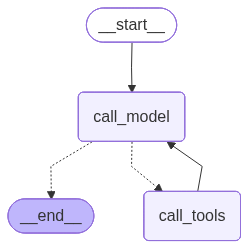

In [ ]:
# 2.2  Visualize the graph

display(Image(agent.get_graph().draw_mermaid_png()))

In [ ]:
# 2.3  Test agent with the same queries

def print_agent_trace(result: dict, print_max_chars: int = 300):
    """Print the full agent trace"""
    for msg in result["messages"]:
        role = msg.__class__.__name__.replace("Message", "")
        content = str(msg.content)[:print_max_chars]
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            content = f"[calls: {', '.join(tc['name'] for tc in msg.tool_calls)}]"
        print(f"  {role:12s} | {content}")


result = agent.invoke(
    {"messages": [("human", "Where is my order #1234?")]}
)

# Print the full message trace
print_agent_trace(result)

  Human        | Where is my order #1234?
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Here’s the latest on order #1234:

- Status: Shipped (shipped 3 days ago)
- Estimated delivery: Tomorrow
- Tracking number: EE12345555RR
- Item: laptop ($999.99)

Would you like me to fetch the live tracking status or send you a tracking link?


In [ ]:
# 2.4  Multi-step query — same result

result = agent.invoke(
    {"messages": [("human", "I want to return a laptop. Order #1234. I changed my mind.")]}
)

print_agent_trace(result)

  Human        | I want to return a laptop. Order #1234. I changed my mind.
  AI           | [calls: check_order_status, search_faq, calculate_refund]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  Tool         | FAQ (return policy): Items can be returned within 30 days of delivery with a receipt.
  Tool         | Refund for $0.00 (placeholder): $0.00
  AI           | Thanks for letting me know. I can help with a return for order #1234.

Current status:
- Laptop: Shippped
- ETA: tomorrow
- Tracking: EE12345555RR

Return eligibility:
- You can return items within 30 days of delivery with a receipt. Since delivery hasn’t occurred yet, you’ll have 30 days from the d


### 2.5 — Adding memory

In [ ]:
# 2.5 Agent does not remember our conversation

result1 = agent.invoke({"messages": [("human", "Where is order #1234?")]})
print_agent_trace(result1)

print()
print("----FOLLOWING MESSAGE-----")
print()
result2 = agent.invoke({"messages": [("human", "Check this order status again")]})
print_agent_trace(result2)

  Human        | Where is order #1234?
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Order #1234 is shipped. 
- Shipped: 3 days ago
- ETA: tomorrow
- Item: laptop ($999.99)
- Tracking number: EE12345555RR

You can track it on the carrier’s site using that tracking number. Want me to set up automated tracking notifications or check for live updates again?

----FOLLOWING MESSAGE-----

  Human        | Check this order status again
  AI           | I’d be happy to check that. Please share the order ID (the one on your confirmation page). If you don’t have it handy, you can also provide the email used at checkout or the approximate order date and I’ll try to locate it. Once I have the ID, I’ll fetch the latest status.


In [ ]:
# 2.6 Adding memory (Full transcript)

from langgraph.checkpoint.memory import InMemorySaver

mem_agent = graph.compile(checkpointer=InMemorySaver())

# Provide a thread ID for a conversation
config = {"configurable": {"thread_id": "customer-42"}}

result1 = mem_agent.invoke(
    {"messages": [("human", "Where is order #1234?")]},
    config=config,
)
print_agent_trace(result1)

print()
print("----SECOND MESSAGE-----")
print()
result2 = mem_agent.invoke(
    {"messages": [("human", "Check this order status again")]},
    config=config,
)
print_agent_trace(result2)

  Human        | Where is order #1234?
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Order #1234 is on its way. Summary:
- Status: shipped (shipped 3 days ago)
- ETA: tomorrow
- Tracking number: EE12345555RR

You can track it with the carrier using that tracking number. Would you like me to send you a tracking link or set up delivery notifications?

----SECOND MESSAGE-----

  Human        | Where is order #1234?
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Order #1234 is on its way. Summary:
- Status: shipped (shipped 3 days ago)
- ETA: tomorrow
- Tracking number: EE12345555RR

You can track it with the carrier using that tracking number. Would you like me to send you a tracking link or set up 

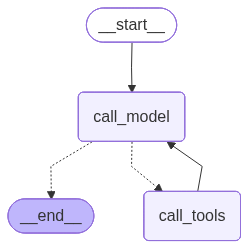

In [ ]:
# 2.7 Visualize (same graph)

display(Image(mem_agent.get_graph().draw_mermaid_png()))

---
## Section 3 — Agent with `create_agent()`

LangChain 1.0 introduced `create_agent` as the recommended way to build
standard ReAct agents. It replaces `create_react_agent` from `langgraph.prebuilt`
(which still works but emits a deprecation warning).

Same agent, ~5 lines.

In [ ]:
# 3.1  Pre-built agent

from langchain.agents import create_agent

prebuilt_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
)

# Test with the same query
result = prebuilt_agent.invoke(
    {"messages": [("human", "Where is my order #1234?")]}
)

print_agent_trace(result)

  Human        | Where is my order #1234?
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Here’s the latest on order #1234:
- Item: Laptop (.$999.99)
- Status: Shipped (shipped 3 days ago)
- ETA: Tomorrow
- Tracking number: EE12345555RR

You can track it on the carrier’s site using that tracking number. Want me to set up delivery notifications or check for updates if the ETA changes?


In [ ]:
# 3.2  Same multi-step query — same result

result = prebuilt_agent.invoke(
    {"messages": [("human", "I want to return my headphones. Order #5678. They're defective.")]}
)

print_agent_trace(result)

  Human        | I want to return my headphones. Order #5678. They're defective.
  AI           | [calls: check_order_status, search_faq, search_faq, search_faq, search_faq]
  Tool         | Order #5678: headphones ($149.99) — Status: processing. Shipped 0 days ago. ETA: 3-5 days. Tracking number: -.
  Tool         | FAQ (return policy): Items can be returned within 30 days of delivery with a receipt.
  Tool         | FAQ (return policy): Items can be returned within 30 days of delivery with a receipt.
  Tool         | FAQ (return policy): Items can be returned within 30 days of delivery with a receipt.
  Tool         | No matching FAQ found. Consider escalating to a human agent.
  AI           | I’m sorry you’re dealing with a defective item.

Here’s what I have for you:
- Order #5678 (headphones, $149.99): Status is processing and not shipped yet. ETA once shipped is 3–5 days.
- Returns: Items can be returned within 30 days of delivery with a receipt.

Defective item assistance:
- I 

In [ ]:
# 3.3  Adding memory

mem_prebuilt_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": "customer-42"}}

result1 = mem_prebuilt_agent.invoke(
    {"messages": [("human", "Where is order #1234?")]},
    config=config,
)
result2 = mem_prebuilt_agent.invoke(
    {"messages": [("human", "Check this order status again")]},
    config=config,
)
print_agent_trace(result2)

  Human        | Where is order #1234?
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Here’s the update for order #1234:
- Item: laptop ($999.99)
- Status: shipped (shipped 3 days ago)
- ETA: tomorrow
- Tracking number: EE12345555RR

You can track it on the carrier’s site using the tracking number. Would you like me to set up delivery alerts or check delivery window closer to the ETA
  Human        | Check this order status again
  AI           | [calls: check_order_status]
  Tool         | Order #1234: laptop ($999.99) — Status: shipped. Shipped 3 days ago. ETA: tomorrow. Tracking number: EE12345555RR.
  AI           | Here’s the latest for order #1234:
- Item: laptop ($999.99)
- Status: shipped (shipped 3 days ago)
- ETA: tomorrow
- Tracking number: EE12345555RR

You can track it on the carrier’s site using the tracking number. Would you l

---
## Section 4 — Gradio Chat UI

Wrap the agent in a chat interface that renders directly in Colab.
No tunnel, no signup — just `gr.ChatInterface`.

**Note:** Gradio ChatInterface keeps a message history. However, we'll also keep a full transcript for our agent.

In [ ]:
# 4.1  Gradio chat interface

import gradio as gr


def chat(message: str, history: list[dict[str, str]]) -> str:
    """Process a chat message through the customer support agent."""
    config = {"configurable": {"thread_id": "customer-42"}}  # needs to be configurable
    result = mem_agent.invoke(
        {"messages": [("human", message)]},
        config=config
    )
    return result["messages"][-1].content


demo = gr.ChatInterface(
    chat,
    type="messages",  # use openai-style {"role": ..., "content": ...}
    title="Acme Customer Support",
    description="Ask about orders, returns, refunds, or products.",
    examples=[
        "Where is my order #1234?",
        "I want to return my headphones. Order #5678.",
        "What's your return policy?",
    ],
)

# demo.launch(share=False, debug=True)
# demo.launch(share=True, debug=True)

**Try it:** interact with your agent through the chat UI above.

To create a **public URL** (shareable with classmates), change `demo.launch()` to:
```python
demo.launch(share=True)
```

---
## Section 5 — MCP Integration (Optional)

MCP (Model Context Protocol) lets you expose tools as a **server** that any agent can connect to.
Here we create a small MCP server in-process and connect it to our agent.

In [ ]:
# 5.1  Install FastMCP
!pip install -q fastmcp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 22.9 MB/s eta 0:00:00


In [ ]:
# 5.2  Create a minimal MCP server

from fastmcp import FastMCP

mcp = FastMCP("Acme Inventory")


@mcp.tool()
def check_inventory(product_name: str) -> str:
    """Check if a product is currently in stock."""
    inventory = {
        "probook laptop": "In stock (23 units)",
        "soundmax headphones": "Low stock (3 units)",
        "keyboard pro": "Out of stock — restocking in 2 weeks",
        "smartdock": "In stock (156 units)",
    }
    result = inventory.get(product_name.lower())
    return result or f"Product '{product_name}' not found in inventory."


@mcp.tool()
def track_shipment(tracking_number: str) -> str:
    """Track a shipment by tracking number."""
    return f"Tracking {tracking_number}: Package is in transit, last scanned in Chicago. ETA: 2 days."


print("MCP server ready. Tools will be discovered via the Client in the next cell.")

MCP server ready. Tools will be discovered via the Client in the next cell.


In [ ]:
# 5.3  Connect MCP tools to the LangGraph agent
#
# In production, the MCP server runs as a separate process.
# Here we use FastMCP's in-process client for simplicity.

from fastmcp import Client


async def get_mcp_tools():
    """Discover tools from the MCP server."""
    async with Client(mcp) as client:
        tools_list = await client.list_tools()
        for t in tools_list:
            print(f"  Discovered: {t.name} — {t.description}")


# In Colab/Jupyter, await works at the top level
await get_mcp_tools()

  Discovered: check_inventory — Check if a product is currently in stock.
  Discovered: track_shipment — Track a shipment by tracking number.


**The takeaway:** MCP tools plug into the same agent loop — the agent doesn't know
or care whether a tool is local (`@tool`) or remote (MCP server).

For the full integration with LangGraph, see the
[langchain-mcp-adapters](https://github.com/langchain-ai/langchain-mcp-adapters) package.

---
## Section 6 — Agentic RAG & Multi-Agents (Self-study)

### Option A — Agentic RAG as a tool

Wirte an Agentic RAG agent for improved search in orders and/or FAQ. Add it to the customer support agent's tool list.

### Option B — Multi-agent with QA review

Build two agents with a sequential handoff:

1. **Support agent** — drafts a response using customer support tools
2. **QA agent** — reviews the draft for policy compliance
   (refund limits, prohibited promises, tone)

If QA rejects → support agent revises. If QA approves → send to customer.

In [ ]:
# Option A - Build an Agentic RAG here

In [ ]:
# Option B - Build a multi-agentic customer support here

### Option B* — Multi-Agents via CrewAI

Try rebuilding the same two-agent setup using [CrewAI](https://crewai.com/).
Notice the difference: CrewAI uses `role`, `goal`, and `backstory` to define agents,
while LangGraph uses explicit graph nodes and edges.

**NOTE:** It's better to install CrewAI in a separate notebook as it'll likely break this environment.

---
## Summary

**What you built today:**
1. A customer support agent in plain Python (~20 lines)
2. The same agent in LangGraph with visualization
3. An Agentic RAG agent with quality grading (exercise)
4. A pre-built agent with `create_agent()` in 5 lines
5. A Gradio chat UI for your agent

**Key takeaway:** Every agent is a loop — the frameworks just add structure around it. Start with the simplest approach that works.